## Regression_housing

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting
9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
11. View Results: R2, mse, mae

---

In [3]:
# 1. load data
import pandas as pd

df = pd.read_csv("regression_housing.csv")

In [2]:
#2. visualize data (EDA)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
# Controlliamo i tipi delle colonne e se ci sono valori nulli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Per le colonne categoriche (tipo "object"),
# può essere utile fare un conteggio di ciascuna categoria:

df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [ ]:
# Controlliamo meglio se ci sono valori nulli
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

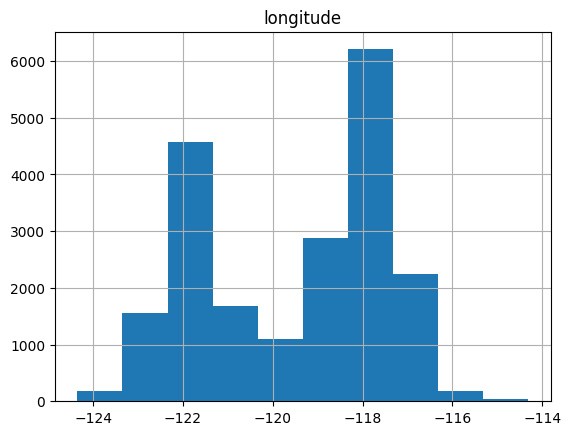

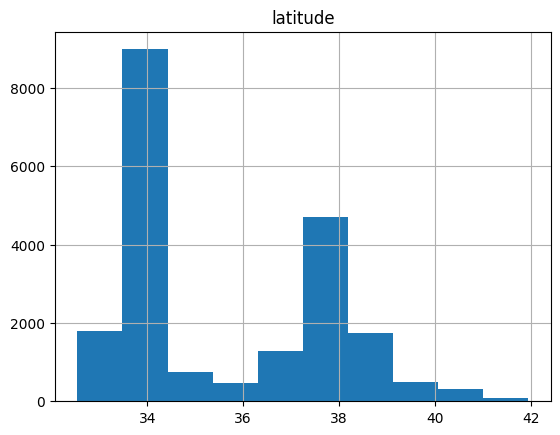

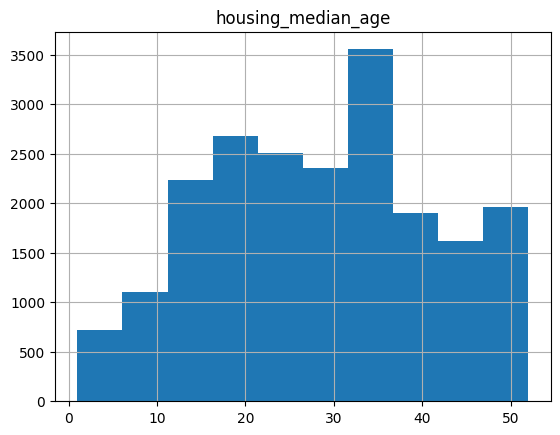

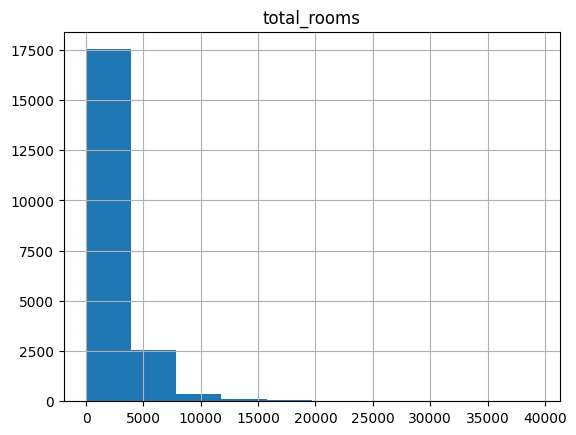

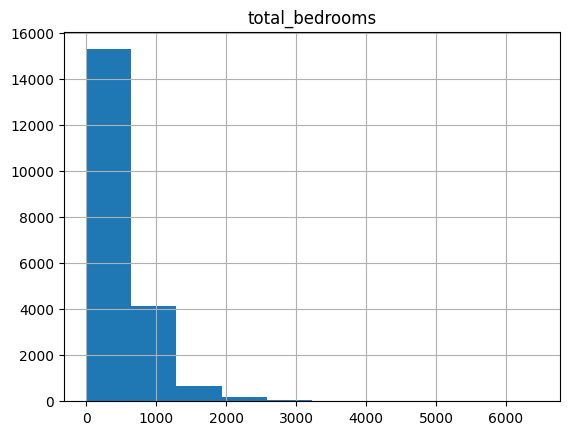

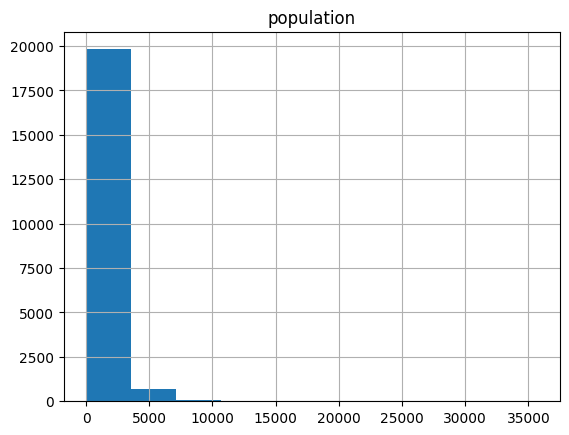

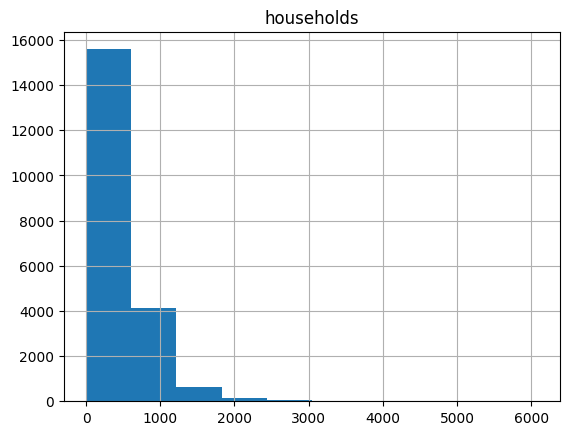

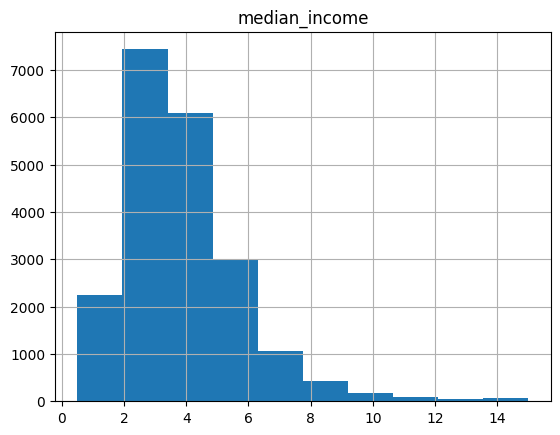

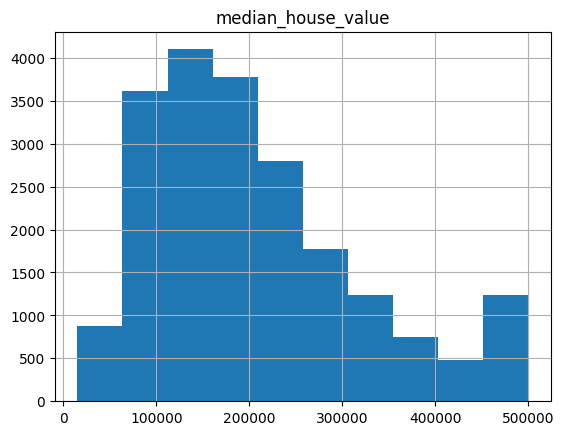

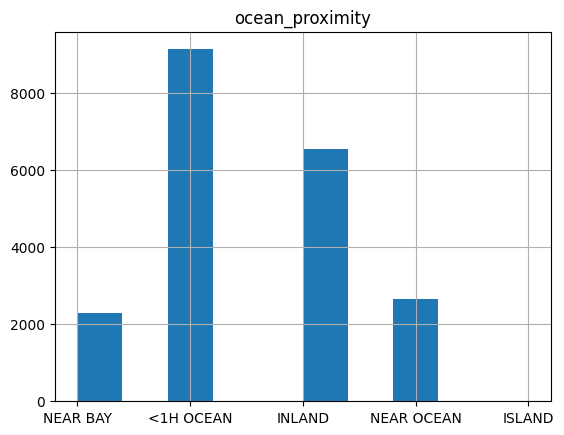

In [ ]:
def plot_histograms(df):
    '''Print histogram for all columns'''
    import matplotlib.pyplot as plt
    for col in df.columns:
        plt.figure()
        df[col].hist()
        plt.title(col)
        plt.show()

plot_histograms(df)

In [6]:
# 3. Clean data: remove columns and/or rows
df_clean = df.copy()
df_clean = df.dropna(subset=["total_bedrooms"])

df_clean

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
# 4. X/y Split

# 'median_house_value' è la variabile che dobbiamo stimare con il modello di regressione
y = df_clean["median_house_value"]
X = df_clean.drop(columns=["median_house_value"])

In [9]:
# 5. train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
# 6. Fill/Scale/Encode Data: apply this only to the training set, then use those same parameters to transform the test set

from sklearn.preprocessing import StandardScaler

ocean_proximity_encoding = {
  "INLAND": 1,
  "<1H OCEAN": 2,
  "NEAR BAY": 3,
  "NEAR OCEAN": 4,
  "ISLAND": 5,
}

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['ocean_proximity'] = X_train_encoded['ocean_proximity'].map(ocean_proximity_encoding)
X_test_encoded['ocean_proximity'] = X_test_encoded['ocean_proximity'].map(ocean_proximity_encoding)

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
9641,-0.636971,0.676616,-0.371848,-0.513114,-0.483473,-0.485229,-0.509155,-0.879984,-1.081124
6821,0.739287,-0.727810,0.342603,-0.554164,-0.462231,-0.235799,-0.451952,-0.439872,-0.049059
4101,0.594155,-0.699627,1.057053,-0.634896,-0.743095,-0.828965,-0.722366,2.028040,-0.049059
2607,-2.223422,2.508476,-0.609998,-0.516307,-0.521236,-0.431465,-0.522156,-0.174738,-0.049059
16019,-1.452717,0.986623,1.850887,-0.225309,-0.613284,-0.590994,-0.592359,3.621956,2.015072
...,...,...,...,...,...,...,...,...,...
528,-1.342617,1.005411,1.850887,-0.509922,-0.518876,-0.535467,-0.618360,-0.219552,0.983007
8543,0.604164,-0.821751,-0.292465,0.091231,0.401601,0.157294,0.328086,-0.350561,-0.049059
4396,0.649205,-0.727810,1.136436,-0.767623,-0.677009,-0.682657,-0.670363,-0.332773,-0.049059
15819,-1.427694,1.000714,1.374587,-0.225765,0.654142,0.566252,0.793509,-1.312548,0.983007


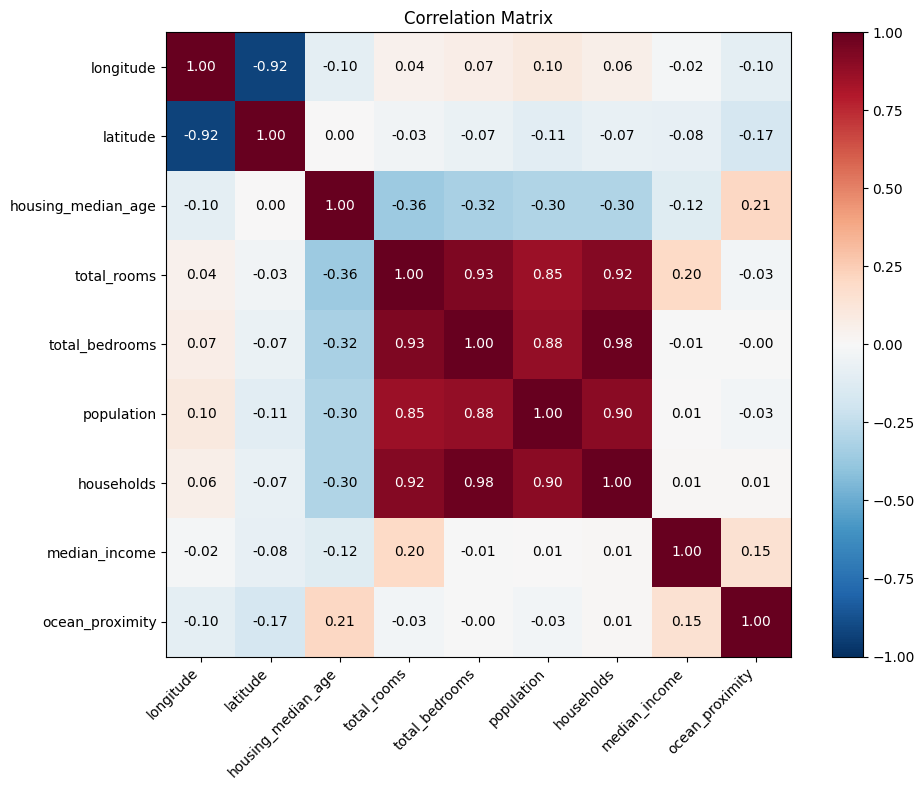

In [14]:
# 7. Check Correlation Matrix on the scaled/encoded training data


def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

show_correlation_matrix(X_train_scaled)

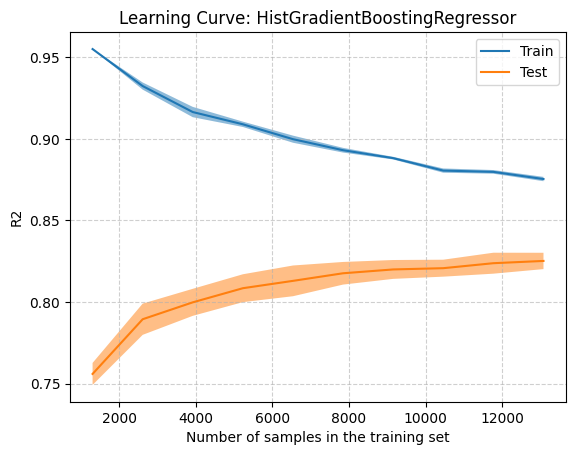

In [17]:
# 8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

from sklearn.ensemble import HistGradientBoostingRegressor
def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """
    import matplotlib.pyplot as plt
    from sklearn.model_selection import LearningCurveDisplay
    import numpy as np

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()

model = HistGradientBoostingRegressor()
plot_learning_curve(model, X_train_scaled, y_train, classification=False)

In [16]:
# 9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)

from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 0.0, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}
Best score: 0.8340040478572741


In [ ]:
'''
Best params: {'early_stopping': True, 'l2_regularization': 0.0, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}
Best score: 0.8340040478572741
'''

In [18]:
# 10. Train Final Model: Retrain the model on the entire training set using the best parameters found

best_model = HistGradientBoostingRegressor(**{'early_stopping': True, 'l2_regularization': 0.0, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 50})
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

In [19]:
# 11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score (class only), or R2, mse, mae (reg only)

def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).round(2)

get_regression_metrics(y_test, y_pred)

,Metric,Value
0,MAE,2.998316e+04
1,MSE,2.038603e+09
2,RMSE,4.515089e+04
3,R2 Score,8.400000e-01


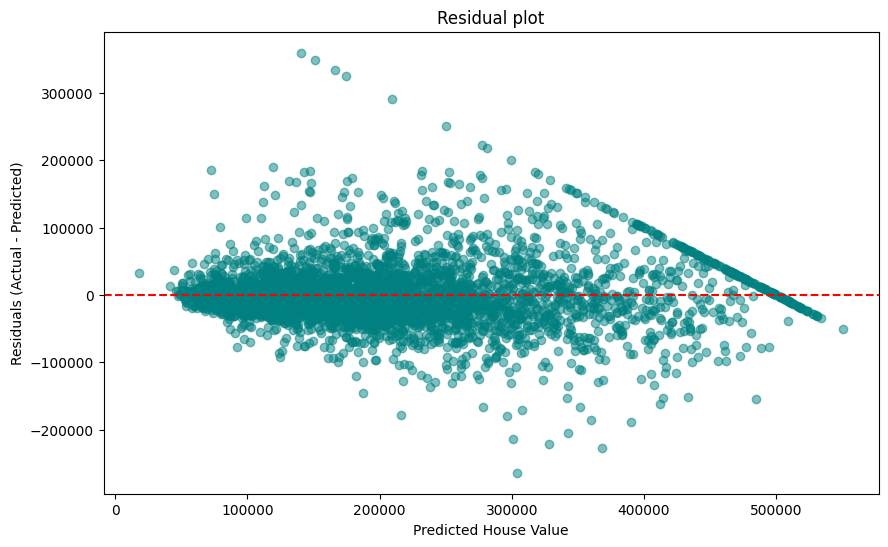

In [20]:
# Bonus: calculate residuals
import matplotlib.pyplot as plt

residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuals, alpha=0.5, color='teal')
ax.axhline(y=0, color='red', linestyle='--') # The "Zero Error" line

ax.set_xlabel("Predicted House Value")
ax.set_ylabel("Residuals (Actual - Predicted)")
ax.set_title("Residual plot")

plt.show()